In [153]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d as Axes3d

In [154]:
data=pd.read_csv("advertising_dataset.csv")

In [155]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [156]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [157]:
data.drop_duplicates()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [158]:
for col in data.columns:
    Q1=data[col].quantile(0.25)
    Q3=data[col].quantile(0.75)
    IQR=Q3-Q1
    Lower_Bound= Q1-1.5*IQR
    Upper_Bound= Q3+1.5*IQR


    data=data[(data[col]>=Lower_Bound) & (data[col]<=Upper_Bound)]

In [160]:
X=data.drop("Sales",axis=1)
X

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [161]:
Y=data["Sales"]

In [162]:
scale=StandardScaler()
X_Scaled=scale.fit_transform(X)
X_Scaled

array([[ 0.97869734,  0.98952135,  1.93299778],
       [-1.19901165,  1.09070498,  0.75131275],
       [-1.51933199,  1.53591293,  1.93790103],
       [ 0.05645636,  1.22561648,  1.40834924],
       [ 0.40024339, -0.83178391,  1.40344598],
       [-1.61906543,  1.73828018,  2.2173867 ],
       [-1.04647815,  0.6522426 , -0.30779084],
       [-0.31079737, -0.23817331, -0.89127846],
       [-1.62023876, -1.41864895, -1.41102374],
       [ 0.62317696, -1.38492107, -0.42056576],
       [-0.94557138, -1.16906267, -0.27346804],
       [ 0.79800381,  0.05863199, -1.26392602],
       [-1.44189191,  0.80739083,  1.77119028],
       [-0.57714432, -1.04764232, -1.10702179],
       [ 0.67363035,  0.65898817,  0.79544207],
       [ 0.57155024,  1.65733328,  1.13376683],
       [ 1.58061798,  1.1109417 ,  1.27596129],
       [-0.90919801, -0.17746313, -0.56276022],
       [ 0.0071763 ,  0.05188642, -0.52353416],
       [ 0.84141719,  0.30821827,  1.15828311],
       [ 1.06435076, -1.21628169, -0.307

In [163]:
X_train,X_test,Y_train,Y_test=train_test_split(X_Scaled,Y,test_size=0.3,random_state=42)


In [164]:
model=LinearRegression()
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [165]:
Y_predict=model.predict(X_test)

In [166]:
print("R2 Score",r2_score(Y_test,Y_predict))

R2 Score 0.9151626818586047


In [167]:
print("Mean Squared Error:",mean_squared_error(Y_test,Y_predict))

Mean Squared Error: 2.450771962736811


In [168]:
X_new={
    'TV':[150,50],
    'Radio':[25,10],
    'Newspaper':[20,5]
}

In [169]:
X_new=pd.DataFrame(X_new)

In [170]:
X_new=scale.fit_transform(X_new)

In [171]:
prediction_new=model.predict(X_new)

In [172]:
prediction_new

array([21.39006938,  8.7971552 ])

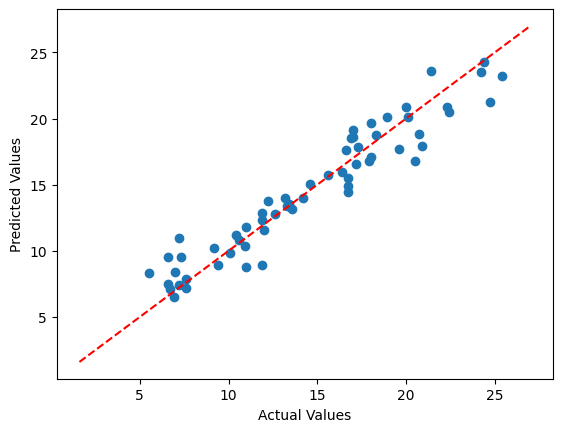

In [181]:
fig=plt.figure()
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.scatter(Y_test,Y_predict)
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()],'r--')
plt.show()

In [174]:
X2=X.drop("Newspaper",axis=1)
y2=data["Sales"]

In [175]:
X2

,TV,Radio
0,230.1,37.8
1,44.5,39.3
2,17.2,45.9
3,151.5,41.3
4,180.8,10.8
...,...,...
195,38.2,3.7
196,94.2,4.9
197,177.0,9.3
198,283.6,42.0


In [176]:
X2_train,X2_test,y2_train,y2_test=train_test_split(X2,y2,test_size=0.2,random_state=42)

In [177]:
model2=LinearRegression()
model2.fit(X2_train,y2_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [178]:
y2_predict=model2.predict(X2_test)

In [179]:
print("Mean Squared Error:",mean_squared_error(y2_test,y2_predict))
print("R2 Score",r2_score(y2_test,y2_predict))

Mean Squared Error: 2.2535639133765466
R2 Score 0.9188405014071852


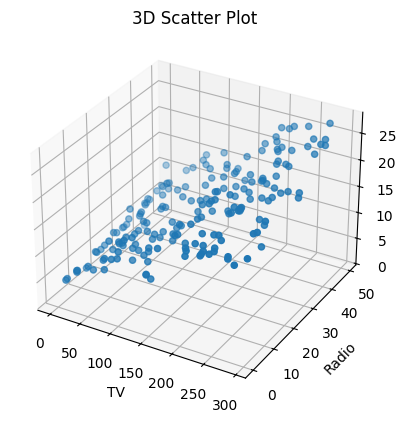

In [180]:
fig=plt.figure()
ax=fig.add_subplot(111,projection="3d")

ax.scatter(data['TV'],data['Radio'],data["Sales"])
ax.set_xlabel("TV")
ax.set_ylabel("Radio")
ax.set_zlabel("Sales")

ax.set_title("3D Scatter Plot")

plt.show()

In [184]:
model_coefficients=model.coef_
model_intercept=model.intercept_
features=X.columns
print("Regression Equation")
Equation=f"Sales = {model_intercept:.2f} + {model_coefficients[0]:.2f} * TV + {model_coefficients[1]:.2f} * Radio + {model_coefficients[2]:.2f} * Newspaper"
Equation


Regression Equation


'Sales = 15.09 + 4.53 * TV + 1.49 * Radio + 0.28 * Newspaper'